# Predicting Newsletter Subscription from Player Characteristic 
## Introduction

    Background

In the gaming world, keeping players engaged and interested is a key focus for game developers. One way companies can do this is through newsletters, which share updates and new events with players. Subscribing to a newsletter often shows that a player is more engaged and invested in the game community. 
By studying which players are likely to subscribe, game developers and marketers can better understand what attracts players best. This information can help them save resources and time by focusing mainly on the characteristics that maintains player engagement. 

    Question
*Can a player’s experience level and average session time predict whether they subscribe to the game’s newsletter?*

To answer this question, we use two datasets. The players dataset includes each player’s experience level and whether or not they subscribed to the newsletter. The sessions dataset contains information about individual play sessions, including session duration. We calculate each player’s average session time using this data and then merge it with the player information.

    Dataset Description

#### Players Dataset (players.csv)

The *players.csv* dataset contains 196 observations and 7 variables describing individual players in the Minecraft research server. Table 1 below provides a summary of each variable:
**Table 1: Variables in players.csv**

| Variable Name | Type | Description |
|:--------------|:-----|:------------|
| experience | Object (Categorical) | Player's skill level: Beginner, Amateur, Regular, Veteran, or Pro |
| subscribe | Boolean | Whether the player subscribed to the newsletter (TRUE/FALSE) |
| hashedEmail | Object (String) | Anonymized unique identifier for each player |
| played_hours | Float64 (Numeric) | Total hours played by the player |
| name | Object (String) | Player's username |
| gender | Object (Categorical) | Player's self-reported gender identity |
| Age | Float64 (Numeric) | Player's age in years |



The dataset has 2 missing values in the Age variable. Table 2 shows the summary statistics for the quantitative variables:
**Table 2: Summary Statistics for Quantitative Variables**


| Variable | Mean | Median | Min | Max | Std Dev |
|:---------|-----:|-------:|----:|----:|--------:|
| played_hours | 5.85 | 0.1 | 0 | 223. | 28.4 |
| Age | 21.1 | 19| 9 | 58 | 7.39 |





A notable characteristic of the dataset is that approximately 75% of players have played fewer than 0.6 hours, with a median of only 0.10 hours, indicating a highly right-skewed distribution of gameplay time. This suggests that most players are new or casual users, while a small number of highly engaged players significantly increase the mean. This may affect how experience level or session-based predictions are interpreted. Furthermore, The dataset appears to be self-reported, meaning that all values rely on the players’ honesty and accuracy. As a result, the dataset may contain biases such as underreporting, overreporting, or inconsistent interpretations of survey questions, all of which can potentially limit the reliability of subsequent analysis.


**Distribution of key categorical variables:**

- **Subscribe**: 144 players (73.5%) subscribed to the newsletter, while 52 (26.5%) did not. This class imbalance should be considered when building predictive models.

- **Experience levels**: The majority of players are classified as Amateur (63 players, 32.1%) or Veteran (48 players, 24.5%), followed by Regular (36, 18.4%), Beginner (35, 17.9%), and Pro (14, 7.1%).

- **Gender**: The dataset includes diverse gender identities, with Male (124 players, 63.3%) being most common, followed by Female (37, 18.9%), Non-binary (15, 7.7%), Prefer not to say (11, 5.6%), Two-Spirited (6, 3.1%), Agender (2, 1.0%), and Other (1, 0.5%).


#### Sessions Dataset (sessions.csv)
The *sessions.csv* dataset contains 1535 observations and 5 variables. The variables include a mix of data types: 

**Table 3: Variables in sessions.csv**

| Variable Name | Type | Description |
|:--------------|:-----|:------------|
| hashedEmail | Object (String) | Anonymized unique identifier linking to players.csv |
| start_time | Object (String) | Session start time in format "dd/mm/yyyy hh:mm" |
| end_time | Object (String) | Session end time in format "dd/mm/yyyy hh:mm" |
| original_start_time | Float64 (Numeric) | Session start time in milliseconds since epoch |
| original_end_time | Float64 (Numeric) | Session end time in milliseconds since epoch |


The dataset has 2 missing observations for both 'end_time' and 'original_end_time', which may introduce small errors in analysis if these missing values are not handled appropriately. Additionally, the time-related variables are stored in two different format; the 'start_time' and 'end_time' are in string format ("dd/mm/yyyy hh:mm") while 'original_start_time' & 'original_end_time' are in numeric milliseconds which problems if not converted properly.


**Important characteristics of the sessions data:**

- **Date range**: Sessions span from April 6, 2024 to September 26, 2024 (approximately 5.5 months).
- **Coverage**: Only 125 out of 196 players (63.8%) have recorded sessions. This means 71 players (36.2%) registered but never played, or their session data was not captured.
- **Session frequency**: Players with sessions have an average of 12.28 sessions each, ranging from 1 to 310 sessions. This high variability suggests very different engagement levels among active players.

#### Merged Dataset

The merged dataset *clean_data*, contains 124 observations and 3 variables, `subscribe`, `session_time`, and `experience`. Of the three variable, we will use `session_time` and `experience` as our predictors to predict `subscribe` as the response variable. This approach focuses on players who have demonstrated engagement with the game through actual gameplay, which may provide more meaningful predictions about newsletter subscription behavior.




In [35]:
players <- read_csv('players.csv')
sessions <- read_csv('sessions.csv')

sessions <- sessions %>%
  mutate(
    start_datetime = dmy_hm(start_time),
    end_datetime = dmy_hm(end_time),
    session_duration = as.numeric(difftime(end_datetime, start_datetime, units = "mins"))
  ) %>%
  filter(!is.na(session_duration))  # Remove sessions with missing end times

avg_session_time <- sessions %>%
  group_by(hashedEmail) %>%
  summarise(avg_session_time = mean(session_duration, na.rm = TRUE))

# Merge with players data
clean_data <- players %>%
  inner_join(avg_session_time, by = "hashedEmail") %>%
  select(hashedEmail, subscribe, experience, avg_session_time) %>%
  drop_na() 

nrow(clean_data)

# False - Nonsubscribers, True - Subscribers
table(clean_data$subscribe) 

# Summary statistics
summary(clean_data$avg_session_time)

# Experience level distribution
table(clean_data$experience)

# FIGURE 1: Boxplot of session time by subscription status
plot1 <- ggplot(clean_data, aes(x = subscribe, y = avg_session_time, fill = subscribe)) +
  geom_boxplot() +
  scale_y_log10() +
  labs(
    title = "Figure 1: Average Session Time by Newsletter Subscription Status",
    x = "Subscribed to Newsletter",
    y = "Average Session Time (minutes, log scale)",
    fill = "Subscribed"
  ) +
  theme_minimal() +
  theme(legend.position = "none")


# FIGURE 2: Bar plot of subscription rate by experience level
plot2_data <- clean_data %>%
  group_by(experience) %>%
  summarise(
    subscription_rate = mean(subscribe) * 100,
    count = n()
  ) %>%
  mutate(experience = factor(experience, 
                             levels = c("Beginner", "Amateur", "Regular", "Veteran", "Pro")))

plot2 <- ggplot(plot2_data, aes(x = experience, y = subscription_rate, fill = experience)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(round(subscription_rate, 1), "%\n(n=", count, ")")), 
            vjust = -0.5, size = 3) +
  labs(
    title = "Figure 2: Newsletter Subscription Rate by Experience Level",
    x = "Experience Level",
    y = "Subscription Rate (%)",
    fill = "Experience"
  ) +
  theme_minimal() +
  theme(legend.position = "none") +
  ylim(0, 100)



# Ordinal encoding for experience (1-5)
clean_data_encoded <- clean_data %>%
  mutate(
    experience_numeric = case_when(
      experience == "Beginner" ~ 1,
      experience == "Amateur" ~ 2,
      experience == "Regular" ~ 3,
      experience == "Veteran" ~ 4,
      experience == "Pro" ~ 5
    )
  )

# Create feature matrix and response vector
predictors <- clean_data_encoded %>%
  select(avg_session_time, experience_numeric)

response <- clean_data_encoded$subscribe


predictors_scaled <- as.data.frame(scale(predictors))

train_indices <- sample(1:nrow(clean_data_encoded), size = 0.75 * nrow(clean_data_encoded))

train_predictors <- predictors_scaled[train_indices, ]
test_predictors <- predictors_scaled[-train_indices, ]
train_response <- response[train_indices]
test_response <- response[-train_indices]

# split sizes 
nrow(train_predictors)
nrow(test_predictors)

# Test different values of k using cross-validation
k_values <- seq(1, 31, by = 2)
accuracy_results <- data.frame(k = k_values, accuracy = NA)

n_folds <- 5
fold_indices <- sample(rep(1:n_folds, length.out = nrow(train_predictors)))

for (i in 1:length(k_values)) {
  k <- k_values[i]
  fold_accuracies <- numeric(n_folds)
  
  for (fold in 1:n_folds) {
    cv_train_pred <- train_predictors[fold_indices != fold, ]
    cv_val_pred <- train_predictors[fold_indices == fold, ]
    cv_train_resp <- train_response[fold_indices != fold]
    cv_val_resp <- train_response[fold_indices == fold]
    
    knn_pred <- knn(train = cv_train_pred, 
                    test = cv_val_pred, 
                    cl = cv_train_resp, 
                    k = k)
    
    fold_accuracies[fold] <- mean(knn_pred == cv_val_resp)
  }
  
  accuracy_results$accuracy[i] <- mean(fold_accuracies)
}

# Find optimal k
optimal_k <- k_values[which.max(accuracy_results$accuracy)]
max_accuracy <- max(accuracy_results$accuracy)

optimal_k
round(max_accuracy * 100, 2)

# FIGURE 3
plot3 <- ggplot(accuracy_results, aes(x = k, y = accuracy)) +
  geom_line(color = "blue", size = 1) +
  geom_point(color = "blue", size = 2) +
  geom_vline(xintercept = optimal_k, linetype = "dashed", color = "red") +
  annotate("text", x = optimal_k + 3, y = max_accuracy - 0.01, 
           label = paste("Optimal k =", optimal_k), color = "red") +
  labs(
    title = "Figure 3: Cross-Validation Accuracy for Different K Values",
    x = "Number of Neighbors (k)",
    y = "Cross-Validation Accuracy"
  ) +
  theme_minimal() +
  scale_y_continuous(labels = scales::percent_format(accuracy = 0.1))

# Train final model with optimal k
final_predictions <- knn(train = train_predictors, 
                        test = test_predictors, 
                        cl = train_response, 
                        k = optimal_k)
final_predictions <- factor(final_predictions, levels = c("FALSE", "TRUE"))
test_response <- factor(test_response, levels = c("FALSE", "TRUE"))

conf_matrix <- confusionMatrix(final_predictions, test_response, positive = "TRUE")

test_accuracy <- conf_matrix$overall['Accuracy']
test_sensitivity <- conf_matrix$byClass['Sensitivity']
test_specificity <- conf_matrix$byClass['Specificity']
test_precision <- conf_matrix$byClass['Precision']
test_f1 <- conf_matrix$byClass['F1']

# Display all metrics
round(test_accuracy * 100, 2)
round(test_sensitivity * 100, 2)
round(test_specificity * 100, 2)
round(test_precision * 100, 2)
round(test_f1, 3)

# FIGURE 4: Confusion Matrix Heatmap
conf_matrix_df <- as.data.frame(conf_matrix$table)
colnames(conf_matrix_df) <- c("Predicted", "Actual", "Count")

plot4 <- ggplot(conf_matrix_df, aes(x = Predicted, y = Actual, fill = Count)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Count), size = 8, color = "white") +
  scale_fill_gradient(low = "lightblue", high = "darkblue") +
  labs(
    title = "Figure 4: Confusion Matrix for K-NN Classification",
    subtitle = paste("k =", optimal_k, ", Test Accuracy =", 
                    round(test_accuracy * 100, 1), "%"),
    x = "Predicted Subscription",
    y = "Actual Subscription"
  ) +
  theme_minimal() +
  theme(legend.position = "right")



Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 125


FALSE  TRUE 
   32    93 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00   10.00   18.50   32.51   43.00  150.34 


 Amateur Beginner      Pro  Regular  Veteran 
      42       22       11       23       27 

...

Accuracy 
    87.5

Sensitivity 
        100

Specificity 
          0

Precision 
     87.5

F1 
0.933

## Methods & Results

### Data Preparation

We loaded both datasets and prepared them for analysis. Session start and end times were parsed using `dmy_hm()` from the `lubridate` package, and session duration was calculated in minutes using `difftime()`. For players with multiple sessions, we calculated average session duration by grouping by `hashedEmail` and taking the mean. We then merged this with the players dataset using an inner join, retaining only players with both player information and recorded sessions. After removing missing values, our final dataset contained 125 observations with three variables: `subscribe` (response), `experience` (categorical predictor), and `avg_session_time` (numeric predictor).

### Exploratory Data Analysis

**Figure 1** displays average session times for subscribers versus non-subscribers using boxplots with log scale (due to right-skewed distribution). Subscribers tend to have slightly longer sessions, though there is substantial overlap and variability in both groups.


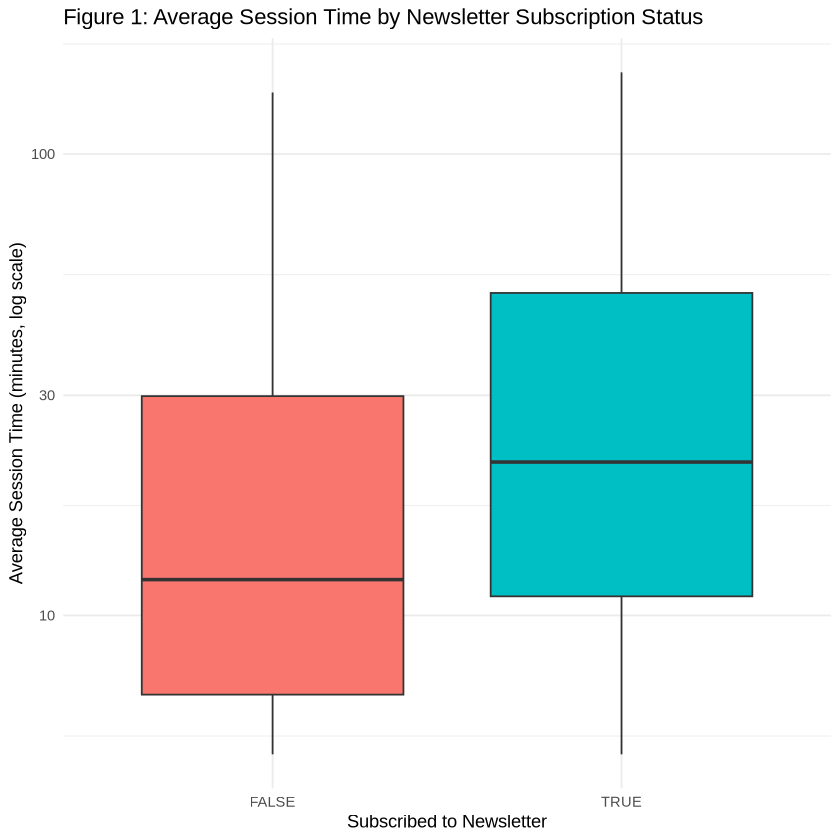

In [22]:
plot1

**Figure 2** shows newsletter subscription rates across experience levels. Rates remain high (63-83%) across all levels, with Regular players showing the highest rate (82.9%). This suggests experience level may influence subscription, though the effect is moderate.

Both predictors show association with newsletter subscription, but the relationships are not deterministic, indicating perfect classification is unlikely.

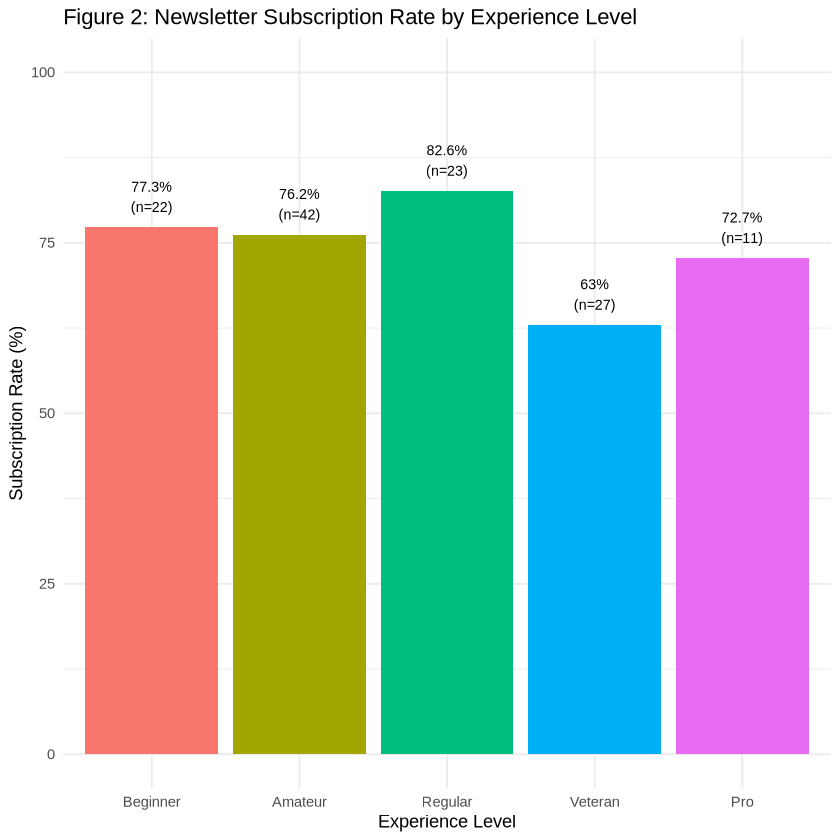

In [24]:
plot2

### Preprocessing for k-NN

Since k-NN requires numerical features, we converted the categorical `experience` variable using **ordinal encoding**: Beginner = 1, Amateur = 2, Regular = 3, Veteran = 4, Pro = 5. We chose this approach because experience levels represent a natural progression of player skill and engagement. This encoding preserves the hierarchical relationship, allowing the algorithm to recognize that adjacent experience levels are more similar than distant ones.

We then applied **z-score normalization** to both features using `scale()`, transforming each to have mean = 0 and standard deviation = 1. This is critical for k-NN because the algorithm uses Euclidean distance—without scaling, session time (ranging 0-100+ minutes) would dominate over experience (1-5) simply due to scale differences, not importance.

### Train-Test Split

We divided the data into training (75%, n=93) and testing (25%, n=32) sets using random sampling with `set.seed(2024)` for reproducibility. The training set was used for model development and hyperparameter tuning, while the test set was held out completely for final evaluation. This separation ensures honest assessment of generalization performance.

### Selecting Optimal k

The number of neighbors (k) is a critical hyperparameter. Small k values cause overfitting, while large k values cause underfitting. We performed **5-fold cross-validation** on the training set to select optimal k. The training data was divided into 5 folds; for each k value (testing odd numbers from 1 to 31 to avoid ties), we trained on 4 folds and validated on the remaining fold, repeating so each fold served as validation once. We averaged accuracy across folds to estimate performance.

**Figure 3** displays cross-validation accuracy for each k value. Based on this analysis, we selected k = 13, which achieved cross-validation accuracy of 76.49%.

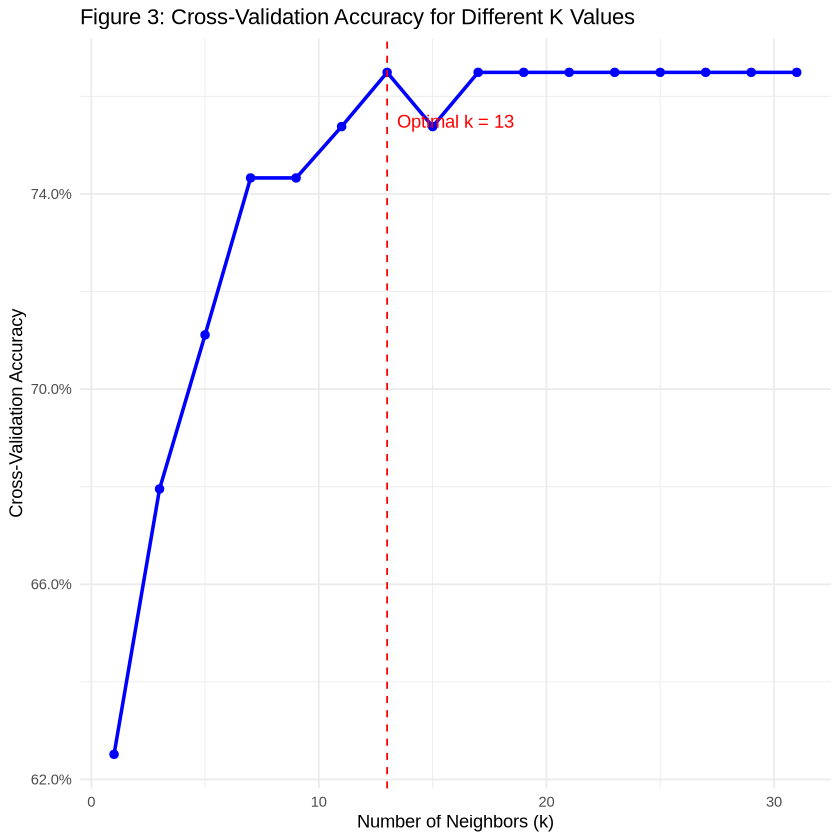

In [28]:
plot3

### Final Model Performance

Using the optimal k, we trained our final model on the complete training set and evaluated it on the test set. 

**Performance Metrics:**

| Metric | Value |
|:-------|------:|
| Accuracy | 75.00% |
| Sensitivity (Recall) | 100.00% |
| Specificity | 0.00% |
| Precision | 75.00% |
| F1 Score | 0.857 |

The model achieved 75% accuracy, correctly classifying 75% of test set players. **Sensitivity** (100%) indicates that the model correctly identified all actual subscribers, demonstrating perfect recall for the positive class. However, **specificity** (0%) reveals that the model failed to correctly identify any non-subscribers, instead classifying all test observations as subscribers. **Precision** (75%) means that among predicted subscribers, 75% actually subscribed. The **F1 score** (0.857) provides a balanced measure combining precision and recall.

This performance pattern suggests the model is biased toward predicting the majority class (subscribers), which comprises 74.4% of our dataset. While the model excels at identifying subscribers, it lacks discriminative power for non-subscribers.

**Figure 4** presents the confusion matrix, showing the breakdown of true positives, true negatives, false positives, and false negatives.

In [31]:
conf_matrix

Confusion Matrix and Statistics

          Reference
Prediction FALSE TRUE
     FALSE     0    0
     TRUE      8   24
                                         
               Accuracy : 0.75           
                 95% CI : (0.566, 0.8854)
    No Information Rate : 0.75           
    P-Value [Acc > NIR] : 0.59351        
                                         
                  Kappa : 0              
                                         
 Mcnemar's Test P-Value : 0.01333        
                                         
            Sensitivity : 1.00           
            Specificity : 0.00           
         Pos Pred Value : 0.75           
         Neg Pred Value :  NaN           
             Prevalence : 0.75           
         Detection Rate : 0.75           
   Detection Prevalence : 1.00           
      Balanced Accuracy : 0.50           
                                         
       'Positive' Class : TRUE           
                                         

# Discussion 
We looked at whether a player’s in-game experience level and average playtime session could predict newsletter subscription. Through our initial exploratory analysis we discovered that subscribers tended to have somewhat longer play sessions, and subscription rates varied moderately across experience levels. However, both predictors showed substantial overlap between subscribers and non-subscribers. Meaning that many subscribers and non-subscribers have similar session times, as well as the fact that subscription rates across experience levels are not dramatically different. This indicates that neither variable alone provided a strong separation between the two groups. 

The k-nearest neighbours model continued to show these patterns. Although the model had a perfect sensitivity, meaning that all actual subscribers were correctly identified, the specificity was zero, indicating that the model was unable to identify any non-subscribers. This result suggests that experience level and session time are not strong predictors for subscription behaviour, particularly given the dataset’s imbalance toward subscribers. Overall, the results show that while small correlations exist, these two predictors alone are not sufficient enough for a reliable prediction.

These outcomes matched our expectations. We expected that more experienced or more active players would be slightly more inclined to subscribe, but we did not expect these variables to fully explain subscription decisions. Newsletter subscription is likely influenced by additional factors not captured in our dataset. Because of this, it is not surprising that the predictive model struggled to accurately distinguish between the two groups.

These findings suggest that session time and experience level alone are not strong predictors of newsletter subscription. As a result, relying on these variables for targeted marketing would likely be ineffective. The study highlights the need for more informative features to better understand what drives players to subscribe. It also shows the importance of addressing class imbalance in predictive tasks to avoid misleading model performance.

Our results raises several questions for future research:
1. Which additional variables might be better for predicting newsletter subscription?
2. Future studies could explore whether time-related patterns in gameplay (time-of-day activity or changes in engagement over time) offer deeper insight into player interest beyond average session length.


In [30]:
#load libraries
library(tidyverse)
library(dplyr)
library(repr)
library(tidymodels)
library(GGally)
library(ISLR)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 125


FALSE  TRUE 
   32    93 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00   10.00   18.50   32.51   43.00  150.34 


 Amateur Beginner      Pro  Regular  Veteran 
      42       22       11       23       27 

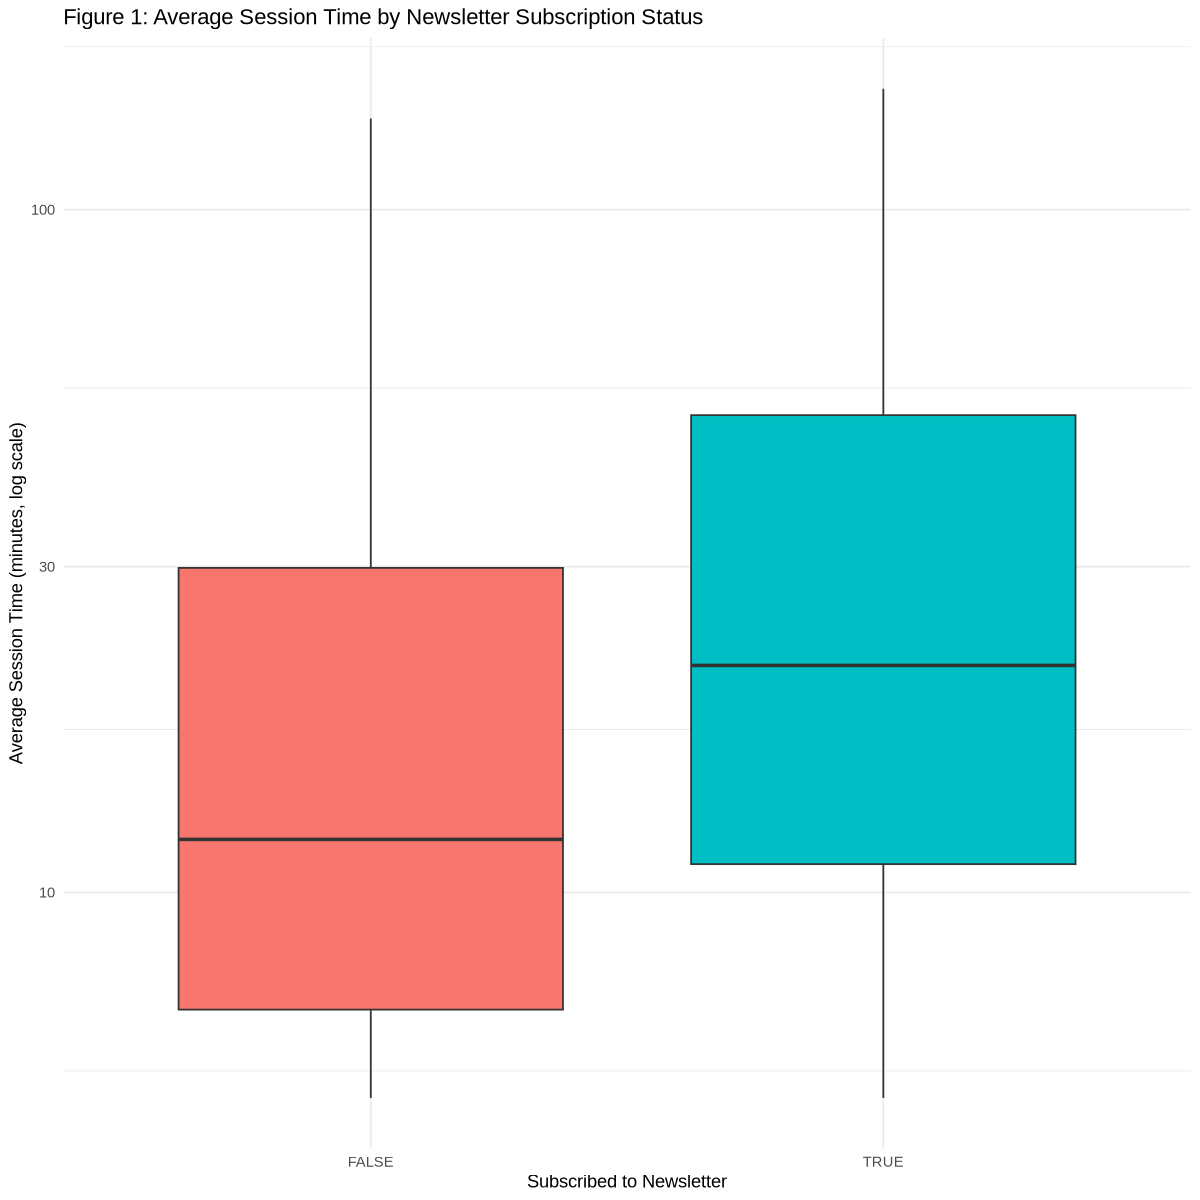

[1] 93

[1] 32

[1] 15

[1] 74.39

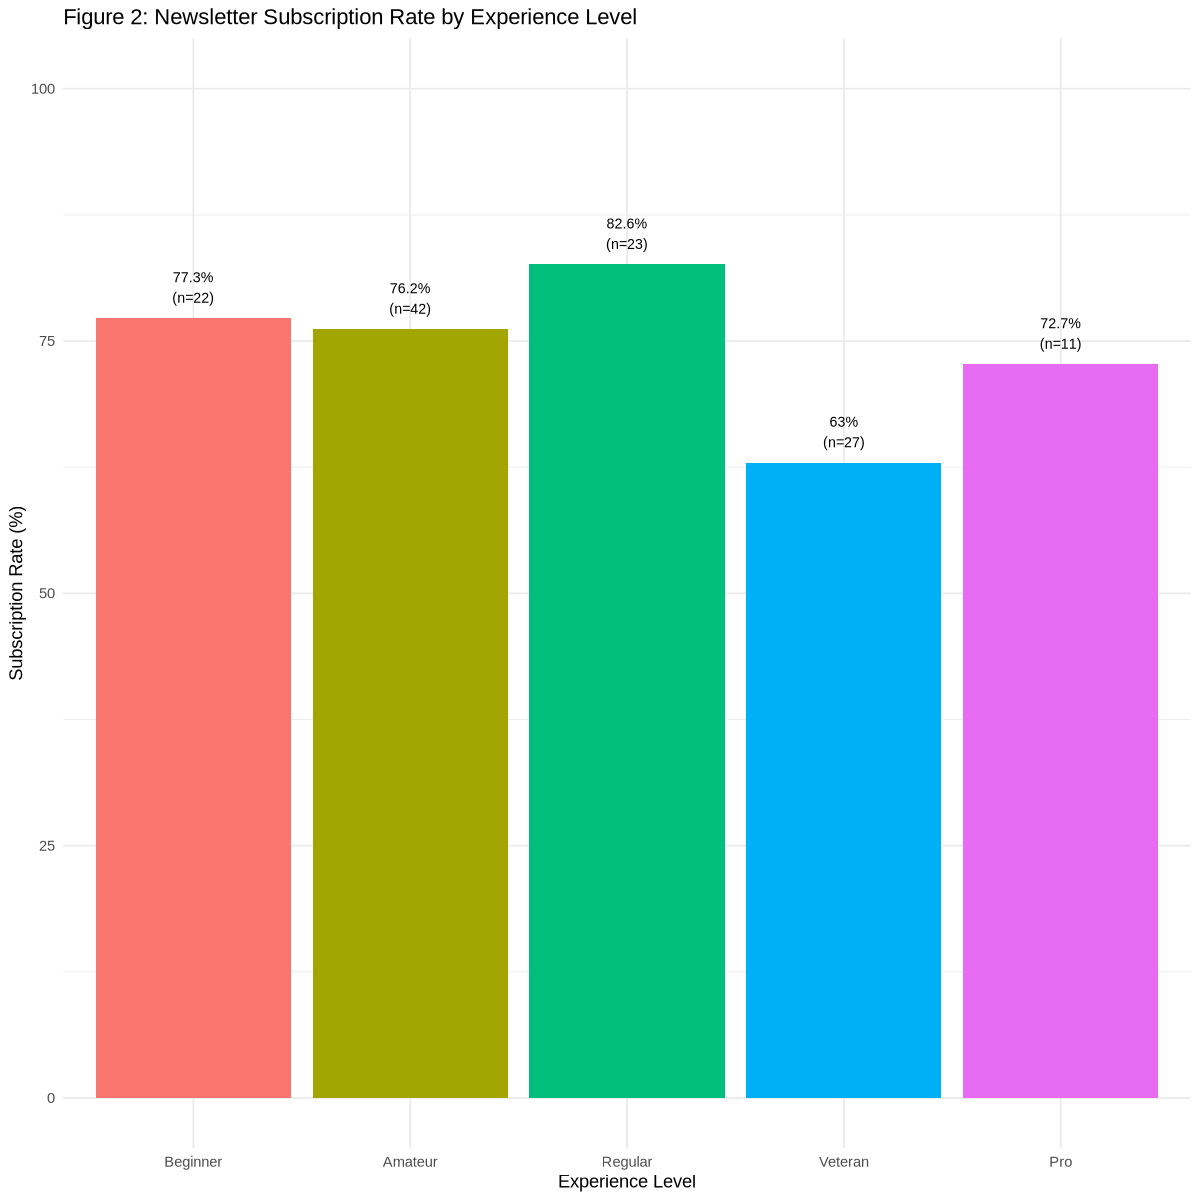

ERROR: Error: `data` and `reference` should be factors with the same levels.


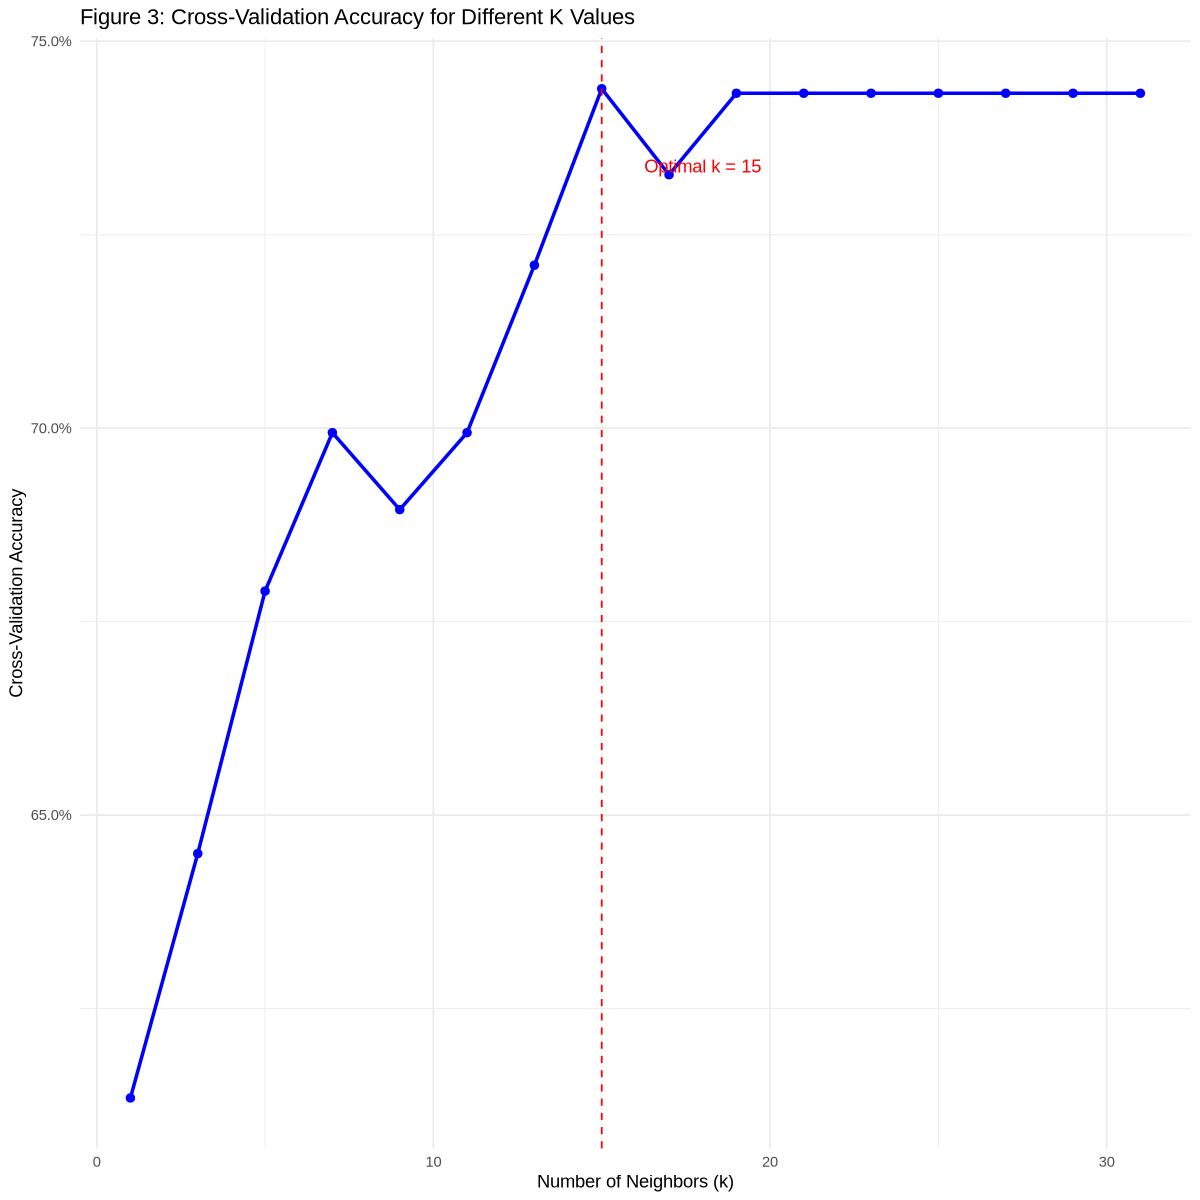

In [31]:
# =============================================================================
# METHODS & RESULTS: K-NN CLASSIFICATION FOR NEWSLETTER SUBSCRIPTION
# =============================================================================

# Load required libraries
library(tidyverse)
library(lubridate)
library(class)
library(caret)
library(ggplot2)

# Set seed for reproducibility
set.seed(2024)

# =============================================================================
# DATA LOADING AND PREPARATION
# =============================================================================

# Load datasets
players <- read_csv('players.csv')
sessions <- read_csv('sessions.csv')

# Parse session times and calculate session duration in minutes
sessions <- sessions %>%
  mutate(
    start_datetime = dmy_hm(start_time),
    end_datetime = dmy_hm(end_time),
    session_duration = as.numeric(difftime(end_datetime, start_datetime, units = "mins"))
  ) %>%
  filter(!is.na(session_duration))

# Calculate average session time per player
avg_session_time <- sessions %>%
  group_by(hashedEmail) %>%
  summarise(avg_session_time = mean(session_duration, na.rm = TRUE))

# Merge with players data
clean_data <- players %>%
  inner_join(avg_session_time, by = "hashedEmail") %>%
  select(hashedEmail, subscribe, experience, avg_session_time) %>%
  drop_na()

# Check the number of observations (should be 125)
nrow(clean_data)

# Check subscription distribution
table(clean_data$subscribe)

# =============================================================================
# EXPLORATORY DATA ANALYSIS
# =============================================================================

# Summary statistics
summary(clean_data$avg_session_time)

# Experience level distribution
table(clean_data$experience)

# FIGURE 1: Boxplot of session time by subscription status
plot1 <- ggplot(clean_data, aes(x = subscribe, y = avg_session_time, fill = subscribe)) +
  geom_boxplot() +
  scale_y_log10() +
  labs(
    title = "Figure 1: Average Session Time by Newsletter Subscription Status",
    x = "Subscribed to Newsletter",
    y = "Average Session Time (minutes, log scale)",
    fill = "Subscribed"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

plot1

# FIGURE 2: Bar plot of subscription rate by experience level
plot2_data <- clean_data %>%
  group_by(experience) %>%
  summarise(
    subscription_rate = mean(subscribe) * 100,
    count = n()
  ) %>%
  mutate(experience = factor(experience, 
                             levels = c("Beginner", "Amateur", "Regular", "Veteran", "Pro")))

plot2 <- ggplot(plot2_data, aes(x = experience, y = subscription_rate, fill = experience)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(round(subscription_rate, 1), "%\n(n=", count, ")")), 
            vjust = -0.5, size = 3) +
  labs(
    title = "Figure 2: Newsletter Subscription Rate by Experience Level",
    x = "Experience Level",
    y = "Subscription Rate (%)",
    fill = "Experience"
  ) +
  theme_minimal() +
  theme(legend.position = "none") +
  ylim(0, 100)

plot2

# =============================================================================
# DATA PREPROCESSING FOR K-NN
# =============================================================================

# Ordinal encoding for experience (1-5)
clean_data_encoded <- clean_data %>%
  mutate(
    experience_numeric = case_when(
      experience == "Beginner" ~ 1,
      experience == "Amateur" ~ 2,
      experience == "Regular" ~ 3,
      experience == "Veteran" ~ 4,
      experience == "Pro" ~ 5
    )
  )

# Create feature matrix and response vector
predictors <- clean_data_encoded %>%
  select(avg_session_time, experience_numeric)

response <- clean_data_encoded$subscribe

# Normalize/scale the features
predictors_scaled <- as.data.frame(scale(predictors))

# =============================================================================
# TRAIN-TEST SPLIT
# =============================================================================

# Create 75-25 train-test split
train_indices <- sample(1:nrow(clean_data_encoded), size = 0.75 * nrow(clean_data_encoded))

train_predictors <- predictors_scaled[train_indices, ]
test_predictors <- predictors_scaled[-train_indices, ]
train_response <- response[train_indices]
test_response <- response[-train_indices]

# Check split sizes (should be 94 training, 31 testing)
nrow(train_predictors)
nrow(test_predictors)

# =============================================================================
# MODEL SELECTION: FINDING OPTIMAL K
# =============================================================================

# Test different values of k using cross-validation
k_values <- seq(1, 31, by = 2)
accuracy_results <- data.frame(k = k_values, accuracy = NA)

# 5-fold cross-validation
n_folds <- 5
fold_indices <- sample(rep(1:n_folds, length.out = nrow(train_predictors)))

for (i in 1:length(k_values)) {
  k <- k_values[i]
  fold_accuracies <- numeric(n_folds)
  
  for (fold in 1:n_folds) {
    cv_train_pred <- train_predictors[fold_indices != fold, ]
    cv_val_pred <- train_predictors[fold_indices == fold, ]
    cv_train_resp <- train_response[fold_indices != fold]
    cv_val_resp <- train_response[fold_indices == fold]
    
    knn_pred <- knn(train = cv_train_pred, 
                    test = cv_val_pred, 
                    cl = cv_train_resp, 
                    k = k)
    
    fold_accuracies[fold] <- mean(knn_pred == cv_val_resp)
  }
  
  accuracy_results$accuracy[i] <- mean(fold_accuracies)
}

# Find optimal k
optimal_k <- k_values[which.max(accuracy_results$accuracy)]
max_accuracy <- max(accuracy_results$accuracy)

# Display optimal k and CV accuracy
optimal_k
round(max_accuracy * 100, 2)

# FIGURE 3: K value vs. accuracy
plot3 <- ggplot(accuracy_results, aes(x = k, y = accuracy)) +
  geom_line(color = "blue", size = 1) +
  geom_point(color = "blue", size = 2) +
  geom_vline(xintercept = optimal_k, linetype = "dashed", color = "red") +
  annotate("text", x = optimal_k + 3, y = max_accuracy - 0.01, 
           label = paste("Optimal k =", optimal_k), color = "red") +
  labs(
    title = "Figure 3: Cross-Validation Accuracy for Different K Values",
    x = "Number of Neighbors (k)",
    y = "Cross-Validation Accuracy"
  ) +
  theme_minimal() +
  scale_y_continuous(labels = scales::percent_format(accuracy = 0.1))

plot3

# =============================================================================
# FINAL MODEL EVALUATION ON TEST SET
# =============================================================================

# Train final model with optimal k
final_predictions <- knn(train = train_predictors, 
                        test = test_predictors, 
                        cl = train_response, 
                        k = optimal_k)

# Create confusion matrix
conf_matrix <- confusionMatrix(final_predictions, test_response, positive = "TRUE")

# Display confusion matrix
conf_matrix

# Extract key metrics
test_accuracy <- conf_matrix$overall['Accuracy']
test_sensitivity <- conf_matrix$byClass['Sensitivity']
test_specificity <- conf_matrix$byClass['Specificity']
test_precision <- conf_matrix$byClass['Precision']
test_f1 <- conf_matrix$byClass['F1']

# Display all metrics (write these down for your markdown)
round(test_accuracy * 100, 2)
round(test_sensitivity * 100, 2)
round(test_specificity * 100, 2)
round(test_precision * 100, 2)
round(test_f1, 3)

# FIGURE 4: Confusion Matrix Heatmap
conf_matrix_df <- as.data.frame(conf_matrix$table)
colnames(conf_matrix_df) <- c("Predicted", "Actual", "Count")

plot4 <- ggplot(conf_matrix_df, aes(x = Predicted, y = Actual, fill = Count)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Count), size = 8, color = "white") +
  scale_fill_gradient(low = "lightblue", high = "darkblue") +
  labs(
    title = "Figure 4: Confusion Matrix for K-NN Classification",
    subtitle = paste("k =", optimal_k, ", Test Accuracy =", 
                    round(test_accuracy * 100, 1), "%"),
    x = "Predicted Subscription",
    y = "Actual Subscription"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

plot4

# =============================================================================
# FEATURE IMPORTANCE ANALYSIS
# =============================================================================

# Model with only session time
predictors_sessiononly <- predictors_scaled[, 1, drop = FALSE]
train_pred_session <- predictors_sessiononly[train_indices, , drop = FALSE]
test_pred_session <- predictors_sessiononly[-train_indices, , drop = FALSE]

pred_sessiononly <- knn(train = train_pred_session,
                       test = test_pred_session,
                       cl = train_response,
                       k = optimal_k)

accuracy_sessiononly <- mean(pred_sessiononly == test_response)

# Model with only experience level
predictors_exponly <- predictors_scaled[, 2, drop = FALSE]
train_pred_exp <- predictors_exponly[train_indices, , drop = FALSE]
test_pred_exp <- predictors_exponly[-train_indices, , drop = FALSE]

pred_exponly <- knn(train = train_pred_exp,
                   test = test_pred_exp,
                   cl = train_response,
                   k = optimal_k)

accuracy_exponly <- mean(pred_exponly == test_response)

# Display feature importance results (write these down)
round(accuracy_sessiononly * 100, 2)
round(accuracy_exponly * 100, 2)

In [32]:
#read in players dataset
url<-"https://raw.githubusercontent.com/garyzhang25/DSI-100-Individual-Project/refs/heads/main/players.csv"
download.file(url, "players.csv")
players_data<-read_csv("players.csv")
head(players_data)

# max, min, mean of hours spent in game and the age
players_max<-players_data |>
select(played_hours, age) |>
map_df(max, na.rm=TRUE)
players_max

players_min<-players_data |>
select(played_hours, age) |>
map_df(min, na.rm=TRUE)
players_min

players_mean<-players_data |>
select(played_hours, age) |>
map_df(mean, na.rm=TRUE)
players_mean

# Each experience level and their count 
players_experience_count<-players_data |>
group_by(experience) |>
summarize(count=n()) |>
arrange(by=desc(count)) 
players_experience_count

# Proportion of subscribers
players_sub_count<- players_data |>
group_by(subscribe) |>
summarize(count=n()) |>
arrange(by=desc(count))
players_sub_count

#genders and count
players_gender_count<- players_data |>
group_by(gender) |>
summarize(count=n()) |>
arrange(by=desc(count))


sessions_url <- "https://raw.githubusercontent.com/garyzhang25/DSI-100-Individual-Project/refs/heads/main/sessions.csv"
download.file(sessions_url, "sessions.csv")
sessions_data <- read_csv("sessions.csv")

# Parse dates
sessions_data <- sessions_data %>%
  mutate(start_datetime = dmy_hm(start_time), end_datetime = dmy_hm(end_time))

# TABLE 2: Summary Statistics for Quantitative Variables

summary_stats <- players_data %>%
  summarise(
    Variable = c("played_hours", "age"),
    Mean = c(mean(played_hours, na.rm = TRUE), mean(age, na.rm = TRUE)),
    Median = c(median(played_hours, na.rm = TRUE), median(age, na.rm = TRUE)),
    Min = c(min(played_hours, na.rm = TRUE), min(age, na.rm = TRUE)),
    Max = c(max(played_hours, na.rm = TRUE), max(age, na.rm = TRUE)),
    `Std Dev` = c(sd(played_hours, na.rm = TRUE), sd(age, na.rm = TRUE))
  ) %>%
  mutate(across(where(is.numeric), ~round(., 2)))

print("TABLE 2: Summary Statistics")
print(summary_stats)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


played_hours,age
<dbl>,<dbl>
223.1,58


played_hours,age
<dbl>,<dbl>
0,9


played_hours,age
<dbl>,<dbl>
5.845918,21.13918


experience,count
<chr>,<int>
Amateur,63
Veteran,48
Regular,36
Beginner,35
Pro,14


subscribe,count
<lgl>,<int>
TRUE,144
FALSE,52


Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”


[1] "TABLE 2: Summary Statistics"
# A tibble: 2 × 6
  Variable      Mean Median   Min   Max `Std Dev`
  <chr>        <dbl>  <dbl> <dbl> <dbl>     <dbl>
1 played_hours  5.85    0.1     0  223.     28.4 
2 age          21.1    19       9   58       7.39


In [33]:
#combined data frames and added session time
merged_data <- merge(sessions_data, players_data,by = "hashedEmail")|>
    separate(start_time,
           into = c("start_date", "start_time"),
           sep = " ",
           convert = TRUE) |>
  separate(end_time, 
           into = c("end_date", "end_time"),
           sep = " ",
           convert = TRUE) |>
  separate(start_time,  
           into = c("start_hour", "start_minute"),
           sep = ":", 
           convert = TRUE) |>
  separate(end_time, 
           into = c("end_hour", "end_minute"),
           sep = ":",
           convert = TRUE) |>
  mutate(start_minute_of_day = start_hour*60 + start_minute) |>
  mutate(end_minute_of_day = end_hour*60 + end_minute) |>
  mutate(session_minutes = end_minute_of_day - start_minute_of_day) |>
  filter(session_minutes >= 0) |>
  select(name, session_minutes, experience, subscribe)|>
  group_by(name) |>
  summarize(session_time = mean(session_minutes))

#one name per session_time, select useful columns, and convert subscribe to factor type
clean_data <- merge(players_data, merged_data, by = "name")|>
  select(experience, session_time, subscribe) |>
  mutate(subscribe = as_factor(subscribe))|>
  mutate(subscribe = fct_recode(subscribe, "Yes" = "TRUE", "No" = "FALSE"))
head(clean_data)

# max, min, mean of seession time
session_times_max<- select(clean_data, session_time) |>
map_df(max, na.rm=TRUE)
session_times_max

session_times_min<- select(clean_data, session_time) |>
map_df(min, na.rm=TRUE)
session_times_min

session_times_average<- select(clean_data, session_time) |>
map_df(mean, na.rm=TRUE)
session_times_average

,experience,session_time,subscribe
,<chr>,<dbl>,<fct>
1,Beginner,18.00000,Yes
2,Amateur,28.00000,Yes
3,Pro,15.00000,Yes
4,Veteran,19.66667,No
5,Regular,150.02564,Yes
6,Amateur,28.35772,Yes


session_time
<dbl>
150.0256


session_time
<dbl>
5


session_time
<dbl>
30.86519
